## First Try

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, auc
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np

In [3]:
file_names = {
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'
}

In [ ]:
# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

sissi_oversampling = df['sissi_oversampling']
multiperm_mono = df['multiperm_mono']

In [ ]:
TP_multiperm = multiperm_mono[multiperm_mono > -4] 
FP_multiperm = multiperm_mono[multiperm_mono <= -4]

TN_sissi = sissi_oversampling[sissi_oversampling < -4]
FN_sissi = sissi_oversampling[sissi_oversampling >= -4]

# Ausgabe der Ergebnisse
print(f"True Positives (TP) für multiperm_mono (Werte > -4): {TP_multiperm}")
print(f"False Positives (FP) für multiperm_mono (Werte <= -4): {FP_multiperm}")

print(f"True Negative (TN) für sissi (Werte < -4): {TN_sissi}")
print(f"False Negative (Fn) für sissi (Werte >= -4): {FN_sissi}")

True Positives (TP) für multiperm_mono (Werte > -4): 7       -3.11
11      -3.46
15      -2.29
16      -3.70
23      -3.85
         ... 
99975   -3.30
99980   -2.44
99982   -3.19
99985   -3.22
99990   -3.67
Name: multiperm_mono, Length: 24439, dtype: float64
False Positives (FP) für multiperm_mono (Werte <= -4): 0       -5.48
1       -7.34
2       -5.99
3       -9.41
4       -7.75
         ... 
99995   -8.72
99996   -6.44
99997   -4.33
99998   -4.54
99999   -6.69
Name: multiperm_mono, Length: 75561, dtype: float64
True Negative (TN) für sissi (Werte < -4): 0       -17.54
1       -33.39
2       -28.15
3       -21.36
4       -21.70
         ...  
99995   -27.31
99996   -18.53
99997   -22.00
99998   -23.58
99999   -17.86
Name: sissi_oversampling, Length: 100000, dtype: float64
False Negative (Fn) für sissi (Werte >= -4): Series([], Name: sissi_oversampling, dtype: float64)


## Second try


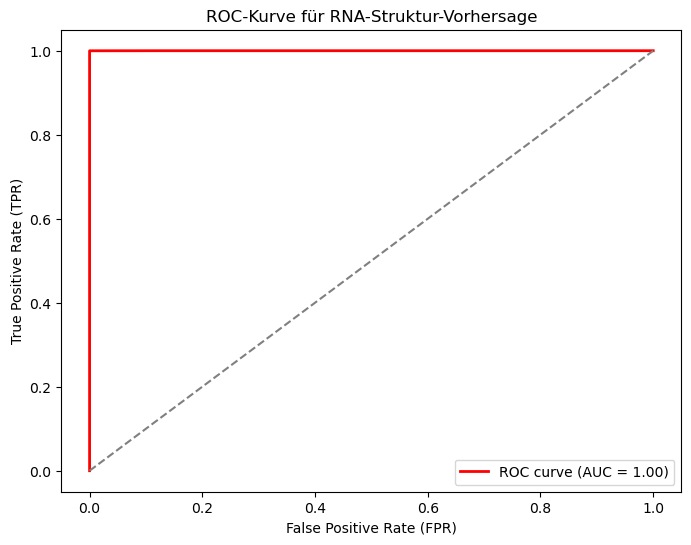

True Positives (TP) für multiperm_mono (Werte > -4): 7       -3.11
11      -3.46
15      -2.29
16      -3.70
23      -3.85
         ... 
99975   -3.30
99980   -2.44
99982   -3.19
99985   -3.22
99990   -3.67
Name: multiperm_mono, Length: 24439, dtype: float64
False Positives (FP) für multiperm_mono (Werte <= -4): 0       -5.48
1       -7.34
2       -5.99
3       -9.41
4       -7.75
         ... 
99995   -8.72
99996   -6.44
99997   -4.33
99998   -4.54
99999   -6.69
Name: multiperm_mono, Length: 75561, dtype: float64
True Negatives (TN) für sissi (Werte < -4): 0       -17.54
1       -33.39
2       -28.15
3       -21.36
4       -21.70
         ...  
99995   -27.31
99996   -18.53
99997   -22.00
99998   -23.58
99999   -17.86
Name: sissi_oversampling, Length: 100000, dtype: float64
False Negatives (FN) für sissi (Werte >= -4): Series([], Name: sissi_oversampling, dtype: float64)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Angenommene Datei-Pfade (passen Sie sie an, falls nötig)
file_names = {
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'
}

# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

# Extrahiere 'sissi_oversampling' und 'multiperm_mono'
sissi_oversampling = df['sissi_oversampling']
multiperm_mono = df['multiperm_mono']

# Erstellen von True Positives (TP) und False Positives (FP) für multiperm_mono
TP_multiperm = multiperm_mono[multiperm_mono > -4]  # Werte > -4
FP_multiperm = multiperm_mono[multiperm_mono <= -4]  # Werte <= -4

# Erstellen von True Negatives (TN) und False Negatives (FN) für sissi_oversampling
TN_sissi = sissi_oversampling[sissi_oversampling < -4]  # Werte < -4
FN_sissi = sissi_oversampling[sissi_oversampling >= -4]  # Werte >= -4

# Labels für das Modell erstellen
# Wir gehen davon aus, dass Werte > -4 als positive Klasse und Werte <= -4 als negative Klasse angesehen werden.
labels_sissi = np.ones(len(sissi_oversampling))  # 1 für 'sissi_oversampling'
labels_multiperm = np.zeros(len(multiperm_mono))  # 0 für 'multiperm_mono'

# Daten zusammenführen
data = pd.concat([sissi_oversampling, multiperm_mono], axis=0)
labels = np.concatenate([labels_sissi, labels_multiperm])

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=0)

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen (Wahrscheinlichkeiten)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (multiperm_mono)

# ROC-Kurve berechnen
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ROC-Kurve plotten
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="red", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Zufallslinie
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC-Kurve für RNA-Struktur-Vorhersage")
plt.legend(loc="lower right")
plt.show()

# Weitere Ausgaben für Debugging
print(f"True Positives (TP) für multiperm_mono (Werte > -4): {TP_multiperm}")
print(f"False Positives (FP) für multiperm_mono (Werte <= -4): {FP_multiperm}")
print(f"True Negatives (TN) für sissi (Werte < -4): {TN_sissi}")
print(f"False Negatives (FN) für sissi (Werte >= -4): {FN_sissi}")

## Third Try

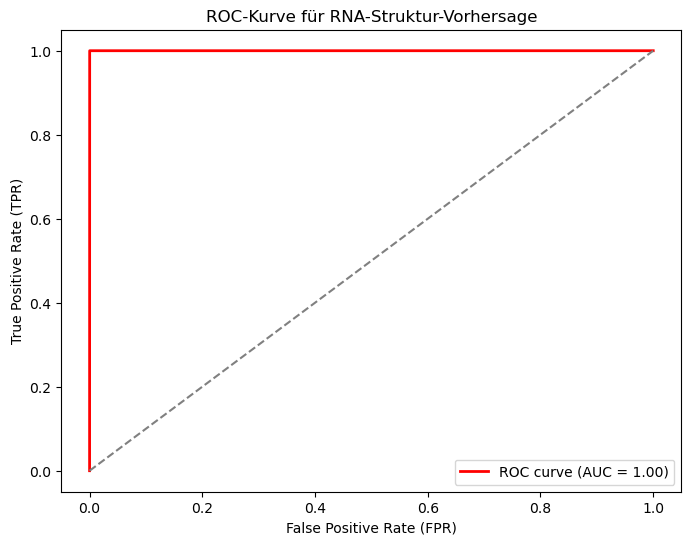

True Positives (TP) für multiperm_mono (Werte > -4): 24439
False Positives (FP) für multiperm_mono (Werte <= -4): 75561
True Negatives (TN) für sissi_oversampling (Werte < -4): 100000
False Negatives (FN) für sissi_oversampling (Werte >= -4): 0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Datei-Pfade
file_names = {
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'
}

# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

# Extrahiere 'sissi_oversampling' und 'multiperm_mono'
sissi_oversampling = df['sissi_oversampling']
multiperm_mono = df['multiperm_mono']

# Erstellen der Labels für das Modell:
# 0 für sissi_oversampling (positive Klasse)
# 1 für multiperm_mono (negative Klasse)
labels_sissi = np.ones(len(sissi_oversampling))  # 1 für 'sissi_oversampling'
labels_multiperm = np.zeros(len(multiperm_mono))  # 0 für 'multiperm_mono'

# Kombiniere die Daten (sissi_oversampling + multiperm_mono)
data = pd.concat([sissi_oversampling, multiperm_mono], axis=0)
labels = np.concatenate([labels_sissi, labels_multiperm])

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=0)

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen (Wahrscheinlichkeiten)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (multiperm_mono)

# ROC-Kurve berechnen
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ROC-Kurve plotten
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="red", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Zufallslinie
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC-Kurve für RNA-Struktur-Vorhersage")
plt.legend(loc="lower right")
plt.show()

# Weitere Ausgaben zur Analyse
print(f"True Positives (TP) für multiperm_mono (Werte > -4): {len(multiperm_mono[multiperm_mono > -4])}")
print(f"False Positives (FP) für multiperm_mono (Werte <= -4): {len(multiperm_mono[multiperm_mono <= -4])}")
print(f"True Negatives (TN) für sissi_oversampling (Werte < -4): {len(sissi_oversampling[sissi_oversampling < -4])}")
print(f"False Negatives (FN) für sissi_oversampling (Werte >= -4): {len(sissi_oversampling[sissi_oversampling >= -4])}")


## With RandomForest

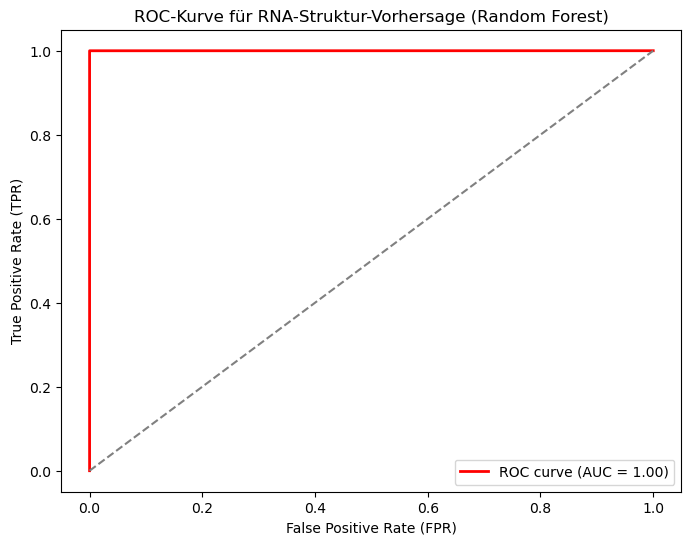

True Positives (TP) für multiperm_mono (Werte > -4): 24439
False Positives (FP) für multiperm_mono (Werte <= -4): 75561
True Negatives (TN) für sissi_oversampling (Werte < -4): 100000
False Negatives (FN) für sissi_oversampling (Werte >= -4): 0


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Datei-Pfade
file_names = {
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'
}

# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

# Extrahiere 'sissi_oversampling' und 'multiperm_mono'
sissi_oversampling = df['sissi_oversampling']
multiperm_mono = df['multiperm_mono']

# Erstellen der Labels für das Modell:
# 0 für sissi_oversampling (negative Klasse)
# 1 für multiperm_mono (positive Klasse)
labels_sissi = np.zeros(len(sissi_oversampling))  # 0 für 'sissi_oversampling'
labels_multiperm = np.ones(len(multiperm_mono))  # 1 für 'multiperm_mono'

# Kombiniere die Daten (sissi_oversampling + multiperm_mono)
data = pd.concat([sissi_oversampling, multiperm_mono], axis=0)
labels = np.concatenate([labels_sissi, labels_multiperm])

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=0)

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Random Forest Classifier initialisieren
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen (Wahrscheinlichkeiten)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (multiperm_mono)

# ROC-Kurve berechnen
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ROC-Kurve plotten
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="red", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Zufallslinie
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC-Kurve für RNA-Struktur-Vorhersage (Random Forest)")
plt.legend(loc="lower right")
plt.show()

# Weitere Ausgaben zur Analyse
print(f"True Positives (TP) für multiperm_mono (Werte > -4): {len(multiperm_mono[multiperm_mono > -4])}")
print(f"False Positives (FP) für multiperm_mono (Werte <= -4): {len(multiperm_mono[multiperm_mono <= -4])}")
print(f"True Negatives (TN) für sissi_oversampling (Werte < -4): {len(sissi_oversampling[sissi_oversampling < -4])}")
print(f"False Negatives (FN) für sissi_oversampling (Werte >= -4): {len(sissi_oversampling[sissi_oversampling >= -4])}")
